In [ ]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<b><font color="red" size="6">10_iris(다중분류)</font></b>

In [22]:
# import
import numpy as np
import seaborn as sns # statsmodel, sklearn 등에서 가져올 수 있음 iris데이터
import pandas as pd # 원핫인코딩 pd.get_dummies
from sklearn.preprocessing import LabelEncoder # 라벨인코딩(문자->숫자)
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.model_selection import train_test_split # 데이터분할(층화추출)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Input, Dropout, add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화

- iris 데이터
1. sepral_length : 꽃받침 길이
2. sepral_width : 꽃받침 넓이
3. petal_length : 꽃잎 길이
4. petal_width : 꽃잎 넓이
5. species : 종(setosa, versicolor, virginica)


In [6]:
# 문자변수의 원핫인코딩
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### 라벨인코딩

In [9]:
# 라벨인코딩
labelEncoder = LabelEncoder()

# labelEncoder.fit(iris['species'])
# iris['y'] = labelEncoder.transform(iris['species'])

iris['y'] = labelEncoder.fit_transform(iris.species)

iris.head()
iris.iloc[::25]

,sepal_length,sepal_width,petal_length,petal_width,species,y
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,0
50,7.0,3.2,4.7,1.4,versicolor,1
75,6.6,3.0,4.4,1.4,versicolor,1
100,6.3,3.3,6.0,2.5,virginica,2
125,7.2,3.2,6.0,1.8,virginica,2


#### 원핫인코딩 방법1

In [11]:
# 원핫인코딩
to_categorical(iris['y'])[::25] # to_categorical의 결과는 numpy배열

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

#### 원핫인코딩 방법2

In [13]:
# 문자변수 원핫인코딩 방법2
iris = sns.load_dataset('iris')
pd.get_dummies(iris.species) # pd.get_dummies 결과는 데이터프레임
pd.get_dummies(iris.species).to_numpy()[::25]

array([[1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1]], dtype=uint8)

## 1. 데이터 생성 및 전처리

In [15]:
# 1. 데이터 생성 및 전처리
iris = sns.load_dataset('iris')
iris.info() # 결측치 있으면 결측치 처리
iris['species'].value_counts() # 타겟변수의 분포

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [19]:
# 독립변수와 타겟변수 분리
iris_X = iris.iloc[:, :-1].to_numpy()
iris_X[:2]
iris_y = iris.iloc[:, -1]
iris_Y = pd.get_dummies(iris_y).values
iris_Y[::50]

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]], dtype=uint8)

In [27]:
# 훈련셋 : 테스트셋 ( 8: 2 )
X_train, X_test, Y_train, Y_test = train_test_split(iris_X, iris_Y,
                                                    #train_size=0.8, #훈련셋비율
                                                    test_size=0.2, # 테스트비율
                                                    stratify=iris_Y, # 층화추출
                                                    random_state=7, # 랜덤시드값
                                                    )
print(iris_X.shape, iris_Y.shape)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(150, 4) (150, 3)
(120, 4) (30, 4) (120, 3) (30, 3)


In [28]:
# 층화추출이 되었는지 확인하는 방법
#iris_Y.argmax(axis=1)
pd.Series(np.argmax(iris_Y, axis=1)).value_counts()

0    50
1    50
2    50
dtype: int64

In [29]:
print(pd.Series(np.argmax(iris_Y, axis=1)).value_counts())
print(pd.Series(np.argmax(Y_train, axis=1)).value_counts())
print(pd.Series(np.argmax(Y_test, axis=1)).value_counts())

0    50
1    50
2    50
dtype: int64
0    40
2    40
1    40
dtype: int64
0    10
2    10
1    10
dtype: int64


## 2. 모델구성(입력4,출력3)

In [36]:
# 2. 모델 구성(입력4, 출력3)
model = Sequential()
model.add(Dense(64, input_dim=4, activation='relu'))

model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(30, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(3, activation='softmax')) # 출력층
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 64)                320       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_10 (Dense)            (None, 128)               8320      
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 50)                6450      
                                                                 
 dropout_2 (Dropout)         (None, 50)                0         
                                                                 
 dense_12 (Dense)            (None, 30)               

## 3. 학습과정 설정

In [37]:
# 3. 학습과정 설정
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

## 4. 학습 : epoch마다 val_accuracy값이 좋아지고 있으면 model 자동 저장(콜백추가)

In [38]:
# 4. 학습 : epoch마다 val_accuracy값이 좋아지고 있으면 model 자동 저장(콜백추가)
# 모델 자동 저장될 경로 : ./model_save_folder/iris-100-val0.8765.h5
import os
model_save_folder = './model_iris/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-val{val_accuracy:.4f}.h5'

# 모델 자동 저장할 콜백 객체
checkpoint = ModelCheckpoint(filepath=file,
                             monitor='val_accuracy', # 모니터링 지표(기본값: val_loss)
                             mode='max', # 저장한거중에 최고치만 저장해라
                             save_best_only=True, # False : 매번 저장
                             verbose=1, # 모델 저장시 로그 출력 (0:로그출력안함)
                             )

# 조기 종료 콜백 객체
earlyStopping = EarlyStopping(patience=40) # monitor 기본값은 val_loss 

# 학습
hist = model.fit(X_train, Y_train,
                 #batch_size=40,
                 epochs=500,
                 validation_split=0.2, # 훈련셋의 20%를 검증셋
                 callbacks=[earlyStopping, checkpoint],
#                  verbose=1,
                 )

Epoch 1/500
1/3 [=========>....................] - ETA: 0s - loss: 1.2576 - accuracy: 0.3438
Epoch 1: val_accuracy improved from -inf to 0.41667, saving model to ./model_iris\iris-001-val0.4167.h5
3/3 [==============================] - 1s 101ms/step - loss: 1.1959 - accuracy: 0.3125 - val_loss: 1.0857 - val_accuracy: 0.4167
Epoch 2/500
1/3 [=========>....................] - ETA: 0s - loss: 1.2030 - accuracy: 0.3438
Epoch 2: val_accuracy did not improve from 0.41667
3/3 [==============================] - 0s 17ms/step - loss: 1.1218 - accuracy: 0.3438 - val_loss: 1.0535 - val_accuracy: 0.2500
Epoch 3/500
1/3 [=========>....................] - ETA: 0s - loss: 1.0592 - accuracy: 0.4688
Epoch 3: val_accuracy did not improve from 0.41667
3/3 [==============================] - 0s 19ms/step - loss: 1.0644 - accuracy: 0.4583 - val_loss: 1.0195 - val_accuracy: 0.2917
Epoch 4/500
1/3 [=========>....................] - ETA: 0s - loss: 1.0267 - accuracy: 0.4062
Epoch 4: val_accuracy improved from 0

Epoch 30/500
1/3 [=========>....................] - ETA: 0s - loss: 0.3087 - accuracy: 0.8750
Epoch 30: val_accuracy did not improve from 0.87500
3/3 [==============================] - 0s 22ms/step - loss: 0.3292 - accuracy: 0.8333 - val_loss: 0.2963 - val_accuracy: 0.8750
Epoch 31/500
1/3 [=========>....................] - ETA: 0s - loss: 0.3800 - accuracy: 0.8750
Epoch 31: val_accuracy did not improve from 0.87500
3/3 [==============================] - 0s 23ms/step - loss: 0.3846 - accuracy: 0.8333 - val_loss: 0.2804 - val_accuracy: 0.8750
Epoch 32/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2797 - accuracy: 0.8438
Epoch 32: val_accuracy did not improve from 0.87500
3/3 [==============================] - 0s 23ms/step - loss: 0.4093 - accuracy: 0.8125 - val_loss: 0.2568 - val_accuracy: 0.8750
Epoch 33/500
1/3 [=========>....................] - ETA: 0s - loss: 0.3154 - accuracy: 0.8750
Epoch 33: val_accuracy improved from 0.87500 to 0.91667, saving model to ./model_iri

3/3 [==============================] - 0s 21ms/step - loss: 0.1824 - accuracy: 0.9375 - val_loss: 0.2642 - val_accuracy: 0.8750
Epoch 60/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2378 - accuracy: 0.8438
Epoch 60: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 20ms/step - loss: 0.2087 - accuracy: 0.8854 - val_loss: 0.2169 - val_accuracy: 0.9167
Epoch 61/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1365 - accuracy: 0.9688
Epoch 61: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 17ms/step - loss: 0.1356 - accuracy: 0.9479 - val_loss: 0.1750 - val_accuracy: 0.9167
Epoch 62/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1137 - accuracy: 0.9688
Epoch 62: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 17ms/step - loss: 0.1372 - accuracy: 0.9479 - val_loss: 0.1617 - val_accuracy: 0.9167
Epoch 63/500
1/3 [=========>....................] 

3/3 [==============================] - 0s 21ms/step - loss: 0.1356 - accuracy: 0.9375 - val_loss: 0.2024 - val_accuracy: 0.9167
Epoch 90/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1358 - accuracy: 0.9375
Epoch 90: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 21ms/step - loss: 0.1491 - accuracy: 0.9479 - val_loss: 0.2040 - val_accuracy: 0.9167
Epoch 91/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0927 - accuracy: 1.0000
Epoch 91: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 19ms/step - loss: 0.0883 - accuracy: 0.9792 - val_loss: 0.1903 - val_accuracy: 0.9583
Epoch 92/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1237 - accuracy: 0.9375
Epoch 92: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 20ms/step - loss: 0.0818 - accuracy: 0.9688 - val_loss: 0.1692 - val_accuracy: 0.9167
Epoch 93/500
1/3 [=========>....................] 

## 5. 모델 할습과정 시각화

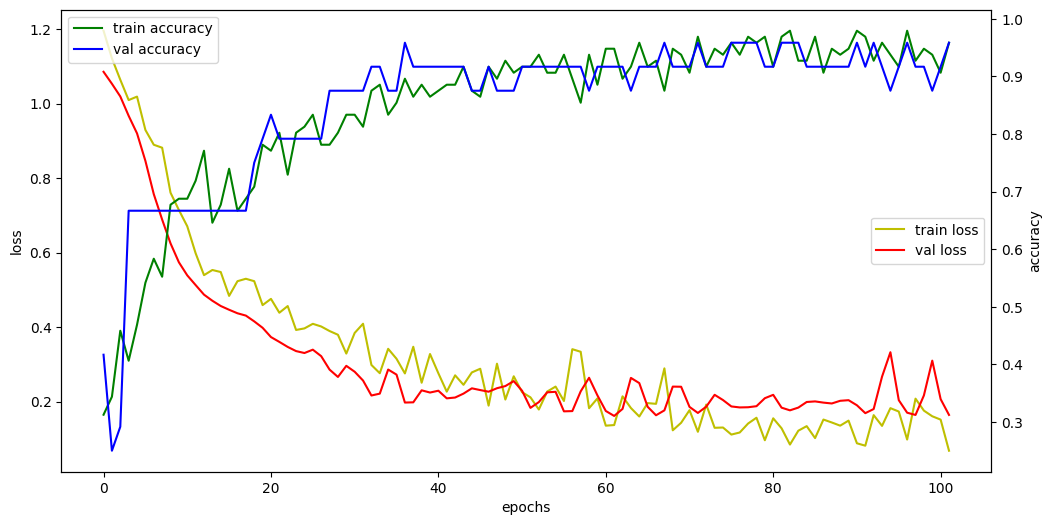

In [39]:
# 5. 모델 할습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

## 6. 모델 평가(evaluate, 교차표, recall, precision))
- evaluate : 테스트셋만 필요
- 교차표, recall, precision : y실제값, y예측값 필요

In [40]:
# 6. 모델 평가(evaluate, 교차표, recall, precision)
# iris-049-val0.9583.h5 모델도 같이 평가
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

### --학습된 모델

In [52]:
# --학습된 모델
loss, acc = model.evaluate(X_test, Y_test)
loss, acc
# 모델의 recall과 precision을 위해서 실제값과 예측값
real = np.argmax(Y_test, axis=1) # 실제값
pred = np.argmax(model.predict(X_test), axis=1) # 예측값
recall = recall_score(real, pred, average='weighted') # average='weighted' : 다중분류
precision = precision_score(real, pred, average='weighted')
f1 = f1_score(real, pred, average='weighted')
print('model loss : ', loss)
print('model accuracy : ', acc)
print('model recall : ', recall)
print('model precision : ', precision)
print('model f1_score : ', f1)

1/1 [==============================] - 0s 20ms/step
model loss :  0.03145141154527664
model accuracy :  1.0
model recall :  1.0
model precision :  1.0
model f1_score :  1.0


### --저장된 모델의 평가

In [51]:
# --저장된 모델의 평가
model2 = load_model('model_iris/iris-049-val0.9583.h5')
loss, acc = model2.evaluate(X_test, Y_test)
pred = model2.predict(X_test).argmax(axis=1)
recall = recall_score(real, pred, average='weighted')
precision = precision_score(real, pred, average='weighted')
f1 = f1_score(real, pred, average='weighted')
print('model2 loss :', loss)
print('model2 acc :', acc)
print('model2 recall :', recall)
print('model2 precision :', precision)
print('model2 f1 :', f1)

1/1 [==============================] - 0s 64ms/step
model2 loss : 0.03531305864453316
model2 acc : 1.0
model2 recall : 1.0
model2 precision : 1.0
model2 f1 : 1.0


## 교차표

In [53]:
# 교차표
pd.crosstab(real, pred,
            rownames=['real'],
            colnames=['pred'])

pred,0,1,2
real,,,
0,10,0,0
1,0,10,0
2,0,0,10


In [54]:
confusion_matrix(real, pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]], dtype=int64)

## 모델 저장 및 사용

In [55]:
# 모델 저장 및 사용
save_model(model, 'model/iris.h5')
model.save('model/iris.h5') # tensorflow2.18이상일 경우 확장자를 .keras로도 사용할 수 있음

## 모델 예측하기

In [57]:
# 모델 예측하기
#iris.loc[100] (6.3, 3.3, 6.0, 2.5) 예측하기
result = model.predict([[6.3, 3.3, 6.1, 2.5]])
np.argmax(result) # virginica로 예측

1/1 [==============================] - 0s 57ms/step


2